<a href="https://colab.research.google.com/github/jahnavi1thoom/GRU/blob/main/GRU.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# LSTM vs GRU Comparision for sentiment analysis

In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, GRU, Dense
from sklearn.model_selection import train_test_split

In [4]:
texts = [
"I love deep learning",
"Artificial intelligence is amazing",
"This course is excellent",
"I am very happy today",
"The movie was fantastic",
"I hate this product",
"This is very bad",
"The service was terrible",
"I am disappointed",
"The experience was awful"

]
labels=[1,1,1,1,1,0,0,0,0,0]

In [6]:
tokenizer=Tokenizer()
tokenizer.fit_on_texts(texts)
sequences=tokenizer.texts_to_sequences(texts)
max_length=max(len(seq) for seq in sequences)
X=pad_sequences(sequences, maxlen=max_length)
y=np.array(labels)
print(X)
print(y)

[[ 0  1  8  9 10]
 [ 0 11 12  2 13]
 [ 0  3 14  2 15]
 [ 1  6  7 16 17]
 [ 0  4 18  5 19]
 [ 0  1 20  3 21]
 [ 0  3  2  7 22]
 [ 0  4 23  5 24]
 [ 0  0  1  6 25]
 [ 0  4 26  5 27]]
[1 1 1 1 1 0 0 0 0 0]


In [7]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [25]:
lstm_model=Sequential([
Embedding(
input_dim=len(tokenizer.word_index)+1,
output_dim=16
),
LSTM(64),
Dense(1,activation='sigmoid')
])

In [26]:

lstm_model.compile(
optimizer='adam',
loss='binary_crossentropy',
metrics=['accuracy']
)
lstm_model. summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [27]:
history_lstm=lstm_model. fit(
X_train,
y_train,
epochs=20,
validation_data=(X_test,y_test),
verbose=1

)

Epoch 1/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.5000 - loss: 0.6926 - val_accuracy: 1.0000 - val_loss: 0.6920
Epoch 2/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.7500 - loss: 0.6921 - val_accuracy: 1.0000 - val_loss: 0.6922
Epoch 3/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - accuracy: 0.7500 - loss: 0.6914 - val_accuracy: 1.0000 - val_loss: 0.6924
Epoch 4/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.8750 - loss: 0.6908 - val_accuracy: 0.5000 - val_loss: 0.6926
Epoch 5/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - accuracy: 0.8750 - loss: 0.6901 - val_accuracy: 0.5000 - val_loss: 0.6928
Epoch 6/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.8750 - loss: 0.6893 - val_accuracy: 0.5000 - val_loss: 0.6930
Epoch 7/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 0.8750 - loss: 0.6885 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 8/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - accuracy: 0.8750 - loss: 0.6875 - val_accuracy: 0.5000 - val_loss: 0.6934
E

In [29]:


lstm_train_loss, lstm_train_acc = lstm_model.evaluate(
X_train,
y_train,
verbose=0
)
print(f"LSTM Train Loss:{lstm_train_loss :.4f}")
print(f"LSTM Train Accuracy:{lstm_train_acc :.4f}")

LSTM Train Loss:0.6628
LSTM Train Accuracy:1.0000


In [32]:
gru_model=Sequential([
Embedding(
input_dim=len(tokenizer.word_index)+1,
output_dim=16,
input_length=max_length
),
GRU(32),
Dense(1,activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [41]:
def predict_sentiment(model,text):
   seq=tokenizer.texts_to_sequences([text])
   padded=pad_sequences(seq,maxlen=max_length)
   prediction=model.predict(padded,verbose=0)[0][0]
   if prediction>=0.5:
       return 'Positive', prediction
   else:
       return 'Negative', prediction

In [42]:
text="I love artificial Intelligence"
result,score=predict_sentiment(
lstm_model,
text
)
print("LSTM Prediction:")
print(result,score)

LSTM Prediction:
Positive 0.5073473


In [43]:
result,score=predict_sentiment(
    gru_model,
    text
)
print("GRU Prediction:")
print(result,score)

GRU Prediction:
Negative 0.49943098


# Dataset working

In [4]:
from tensorflow.keras.datasets import imdb

### Task 1: Dataset Analysis

Let's load the IMDB movie review dataset and perform an exploratory analysis to understand its characteristics.

In [5]:
# Load the IMDB dataset
# num_words=10000 means we only keep the top 10,000 most frequently occurring words
# This helps in reducing vocabulary size and focuses on important words.
(X_train_imdb, y_train_imdb), (X_test_imdb, y_test_imdb) = imdb.load_data(num_words=10000)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [6]:
import numpy as np
# Combine train and test sets for overall analysis
all_reviews = np.concatenate((X_train_imdb, X_test_imdb), axis=0)
all_labels = np.concatenate((y_train_imdb, y_test_imdb), axis=0)

print(f"Total number of reviews: {len(all_reviews)}")
print(f"Number of training reviews: {len(X_train_imdb)}")
print(f"Number of testing reviews: {len(X_test_imdb)}")

Total number of reviews: 50000
Number of training reviews: 25000
Number of testing reviews: 25000


In [7]:
# Count positive and negative reviews
positive_reviews = np.sum(all_labels == 1)
negative_reviews = np.sum(all_labels == 0)

print(f"Number of positive reviews: {positive_reviews}")
print(f"Number of negative reviews: {negative_reviews}")
print(f"Proportion of positive reviews: {positive_reviews / len(all_labels):.2f}")
print(f"Proportion of negative reviews: {negative_reviews / len(all_labels):.2f}")

Number of positive reviews: 25000
Number of negative reviews: 25000
Proportion of positive reviews: 0.50
Proportion of negative reviews: 0.50


In [8]:
# Calculate review lengths
review_lengths = [len(review) for review in all_reviews]

print(f"Average review length: {np.mean(review_lengths):.2f} words")
print(f"Longest review: {np.max(review_lengths)} words")
print(f"Shortest review: {np.min(review_lengths)} words")

Average review length: 234.76 words
Longest review: 2494 words
Shortest review: 7 words


### Fixing `pad_sequences` `NameError`

The `NameError: name 'pad_sequences' is not defined` in the previous step indicates that the `pad_sequences` function was not recognized, likely because its import statement in the initial setup cell (`zjQeacZDq7R1`) was not re-executed after a kernel restart, or the cell itself was not run. To ensure it's available for padding, I'll explicitly import it here.

In [9]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

### Task 2: Text Preprocessing

The IMDB dataset loaded via `imdb.load_data` already provides reviews as integer sequences, meaning they are already tokenized and have some basic cleaning applied, with a vocabulary limited by `num_words`.

To explicitly demonstrate the preprocessing steps, we'll first convert a sample integer sequence back to human-readable text. Then, we will define and apply functions for lowercase conversion, HTML tag removal, punctuation removal, and stopword removal to this sample. Finally, we will prepare the full IMDB dataset by determining a consistent sequence length and padding.

In [10]:
import re
import string
import nltk
from nltk.corpus import stopwords

# Download NLTK stopwords (if not already downloaded)
try:
    stopwords.words('english')
except LookupError:
    nltk.download('stopwords')

# Get the word index mapping
word_index = imdb.get_word_index()

# Create a reverse word index to convert integers back to words
# The indices are offset by 3 because 0, 1, and 2 are reserved for "padding," "start of sequence," and "unknown."
reverse_word_index = dict([(value, key) for (key, value) in word_index.items()])

def decode_review(text_sequence):
    return " ".join([reverse_word_index.get(i - 3, "?") for i in text_sequence])

# Decode a sample review from the training set
sample_review_idx = 0
decoded_sample_review = decode_review(X_train_imdb[sample_review_idx])

print(f"Original integer sequence (first 20 elements): {X_train_imdb[sample_review_idx][:20]}")
print(f"\nDecoded sample review:\n{decoded_sample_review[:500]}...")

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


Original integer sequence (first 20 elements): [1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25]

Decoded sample review:
? this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert ? is an amazing actor and now the same being director ? father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for ? and would recommend it to ever...


In [11]:
def to_lowercase(text):
    return text.lower()

def remove_html_tags(text):
    clean = re.compile('<.*?>')
    return re.sub(clean, '', text)

def remove_punctuation(text):
    translator = str.maketrans('', '', string.punctuation)
    return text.translate(translator)

def remove_stopwords(text):
    stop_words = set(stopwords.words('english'))
    words = text.split()
    filtered_words = [word for word in words if word.lower() not in stop_words]
    return " ".join(filtered_words)

# --- Demonstrate preprocessing on the decoded sample review ---
print(f"Original decoded review:\n{decoded_sample_review[:200]}...")

# 1. Lowercase conversion
lower_case_review = to_lowercase(decoded_sample_review)
print(f"\nAfter lowercase conversion:\n{lower_case_review[:200]}...")

# 2. HTML tag removal (IMDB reviews are generally clean, but for demonstration)
html_removed_review = remove_html_tags(lower_case_review)
print(f"\nAfter HTML tag removal:\n{html_removed_review[:200]}...")

# 3. Punctuation removal
punctuation_removed_review = remove_punctuation(html_removed_review)
print(f"\nAfter punctuation removal:\n{punctuation_removed_review[:200]}...")

# 4. Stopword removal
stopword_removed_review = remove_stopwords(punctuation_removed_review)
print(f"\nAfter stopword removal:\n{stopword_removed_review[:200]}...")

Original decoded review:
? this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert ? is an amazing actor and now the sa...

After lowercase conversion:
? this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert ? is an amazing actor and now the sa...

After HTML tag removal:
? this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert ? is an amazing actor and now the sa...

After punctuation removal:
 this film was just brilliant casting location scenery story direction everyones really suited the part they played and you could just imagine being there robert  is an amazing actor and now the same ...

After stopword removal:
film brilliant casting location scenery story direct

In [12]:
# Determine a suitable maximum sequence length for padding
# We'll use the 90th percentile of review lengths to balance information retention and computational cost.
# The `review_lengths` list was calculated in Task 1.

MAX_SEQUENCE_LENGTH = int(np.percentile(review_lengths, 90))
print(f"Selected maximum sequence length for padding (90th percentile): {MAX_SEQUENCE_LENGTH}")

# Pad sequences to MAX_SEQUENCE_LENGTH
X_train_padded = pad_sequences(X_train_imdb, maxlen=MAX_SEQUENCE_LENGTH)
X_test_padded = pad_sequences(X_test_imdb, maxlen=MAX_SEQUENCE_LENGTH)

print(f"Shape of X_train_padded: {X_train_padded.shape}")
print(f"Shape of X_test_padded: {X_test_padded.shape}")
print(f"Shape of y_train_imdb: {y_train_imdb.shape}")
print(f"Shape of y_test_imdb: {y_test_imdb.shape}")

Selected maximum sequence length for padding (90th percentile): 457
Shape of X_train_padded: (25000, 457)
Shape of X_test_padded: (25000, 457)
Shape of y_train_imdb: (25000,)
Shape of y_test_imdb: (25000,)


### Task 3: Build SimpleRNN Model

We will now build, compile, and train a SimpleRNN model. The architecture will consist of an Embedding Layer, followed by a SimpleRNN layer, a Dense layer, and finally an Output layer with a sigmoid activation for binary classification.

In [13]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Dense
import tensorflow as tf

# Define the vocabulary size (from imdb.load_data num_words)
VOCAB_SIZE = 10000

# Define the embedding dimension
EMBEDDING_DIM = 128

simple_rnn_model = Sequential([
    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBEDDING_DIM
    ),
    tf.keras.layers.SimpleRNN(128),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])

simple_rnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [14]:
simple_rnn_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Train the SimpleRNN model
history_simple_rnn = simple_rnn_model.fit(
    X_train_padded,
    y_train_imdb,
    epochs=10, # You can adjust epochs as needed
    validation_data=(X_test_padded, y_test_imdb),
    batch_size=32,
    verbose=1
)

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 41s 47ms/step - accuracy: 0.6663 - loss: 0.5890 - val_accuracy: 0.7892 - val_loss: 0.4698
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 34s 44ms/step - accuracy: 0.7693 - loss: 0.4788 - val_accuracy: 0.7690 - val_loss: 0.4923
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 41s 44ms/step - accuracy: 0.8211 - loss: 0.4007 - val_accuracy: 0.7965 - val_loss: 0.4547
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 35s 44ms/step - accuracy: 0.8560 - loss: 0.3369 - val_accuracy: 0.8257 - val_loss: 0.4722
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 35s 44ms/step - accuracy: 0.9037 - loss: 0.2488 - val_accuracy: 0.8174 - val_loss: 0.5043
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 42s 45ms/step - accuracy: 0.8591 - loss: 0.3278 - val_accuracy: 0.7223 - val_loss: 0.5556
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 35s 44ms/step - accuracy: 0.8982 - loss: 0.2515 - val_accuracy: 0.7603 - val_loss: 0.5819
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 35s 44ms/step - accuracy: 0.9301 - loss: 0.1824 - 

In [15]:
# Evaluate the SimpleRNN model
simple_rnn_loss, simple_rnn_acc = simple_rnn_model.evaluate(
    X_test_padded,
    y_test_imdb,
    verbose=0
)

print(f"SimpleRNN Test Loss: {simple_rnn_loss:.4f}")
print(f"SimpleRNN Test Accuracy: {simple_rnn_acc:.4f}")

SimpleRNN Test Loss: 0.5949
SimpleRNN Test Accuracy: 0.7403


### Task 4: Build LSTM Model

Now, we'll build, compile, and train an LSTM model. The architecture will be similar to the SimpleRNN model, using an Embedding Layer, followed by an LSTM layer, a Dense layer, and an Output layer with a sigmoid activation.

In [16]:
from tensorflow.keras.layers import LSTM
lstm_model_imdb = Sequential([
    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBEDDING_DIM
    ),
    LSTM(128), # LSTM layer with 128 units
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])

lstm_model_imdb.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [17]:
lstm_model_imdb.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Train the LSTM model
history_lstm_imdb = lstm_model_imdb.fit(
    X_train_padded,
    y_train_imdb,
    epochs=10, # You can adjust epochs as needed
    validation_data=(X_test_padded, y_test_imdb),
    batch_size=32,
    verbose=1
)

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 27s 28ms/step - accuracy: 0.7840 - loss: 0.4544 - val_accuracy: 0.8589 - val_loss: 0.3385
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 21s 27ms/step - accuracy: 0.8854 - loss: 0.2804 - val_accuracy: 0.8622 - val_loss: 0.3272
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 22s 28ms/step - accuracy: 0.9237 - loss: 0.2034 - val_accuracy: 0.8559 - val_loss: 0.3405
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 40s 27ms/step - accuracy: 0.9479 - loss: 0.1412 - val_accuracy: 0.8640 - val_loss: 0.3656
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 22s 28ms/step - accuracy: 0.9636 - loss: 0.1037 - val_accuracy: 0.8597 - val_loss: 0.3934
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 22s 28ms/step - accuracy: 0.9767 - loss: 0.0677 - val_accuracy: 0.8654 - val_loss: 0.4964
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 21s 27ms/step - accuracy: 0.9786 - loss: 0.0608 - val_accuracy: 0.8641 - val_loss: 0.5650
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 41s 28ms/step - accuracy: 0.9869 - loss: 0.0398 - 

In [18]:
# Evaluate the LSTM model
lstm_loss_imdb, lstm_acc_imdb = lstm_model_imdb.evaluate(
    X_test_padded,
    y_test_imdb,
    verbose=0
)

print(f"LSTM Test Loss: {lstm_loss_imdb:.4f}")
print(f"LSTM Test Accuracy: {lstm_acc_imdb:.4f}")

LSTM Test Loss: 0.7570
LSTM Test Accuracy: 0.8403


### Task 5: Build GRU Model

Now, we'll build, compile, and train a GRU model. The architecture will be similar to the LSTM model, using an Embedding Layer, followed by a GRU layer, a Dense layer, and an Output layer with a sigmoid activation.

In [19]:
from tensorflow.keras.layers import GRU

gru_model_imdb = Sequential([
    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBEDDING_DIM
    ),
    GRU(128), # GRU layer with 128 units
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])

gru_model_imdb.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [20]:
gru_model_imdb.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Train the GRU model
history_gru_imdb = gru_model_imdb.fit(
    X_train_padded,
    y_train_imdb,
    epochs=10, # You can adjust epochs as needed
    validation_data=(X_test_padded, y_test_imdb),
    batch_size=32,
    verbose=1
)

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 24s 28ms/step - accuracy: 0.8046 - loss: 0.4155 - val_accuracy: 0.8763 - val_loss: 0.3014
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 22s 28ms/step - accuracy: 0.9175 - loss: 0.2118 - val_accuracy: 0.8965 - val_loss: 0.2546
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 22s 28ms/step - accuracy: 0.9555 - loss: 0.1208 - val_accuracy: 0.8848 - val_loss: 0.3375
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 25s 32ms/step - accuracy: 0.9770 - loss: 0.0680 - val_accuracy: 0.8798 - val_loss: 0.4203
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 25s 32ms/step - accuracy: 0.9859 - loss: 0.0422 - val_accuracy: 0.8771 - val_loss: 0.4990
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 22s 28ms/step - accuracy: 0.9918 - loss: 0.0249 - val_accuracy: 0.8632 - val_loss: 0.5822
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 41s 28ms/step - accuracy: 0.9931 - loss: 0.0195 - val_accuracy: 0.8647 - val_loss: 0.6716
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 22s 28ms/step - accuracy: 0.9960 - loss: 0.0124 - 

In [21]:
# Evaluate the GRU model
gru_loss_imdb, gru_acc_imdb = gru_model_imdb.evaluate(
    X_test_padded,
    y_test_imdb,
    verbose=0
)

print(f"GRU Test Loss: {gru_loss_imdb:.4f}")
print(f"GRU Test Accuracy: {gru_acc_imdb:.4f}")

GRU Test Loss: 0.8068
GRU Test Accuracy: 0.8707


### Task 6: Performance Comparison

Now, let's gather all the metrics and create a comparison table for the SimpleRNN, LSTM, and GRU models. We'll compare them based on:

*   **Accuracy (Test)**
*   **Precision (Test)**
*   **Recall (Test)**
*   **F1 Score (Test)**
*   **Training Time**
*   **Validation Accuracy (Last Epoch)**
*   **Validation Loss (Last Epoch)**
*   **Number of Parameters**

In [22]:
from sklearn.metrics import precision_score, recall_score, f1_score
import time

# --- Helper function to get metrics ----
def get_model_metrics(model, X_test, y_test, history, model_name):
    # Predictions for Precision, Recall, F1 Score
    y_pred_proba = model.predict(X_test_padded, verbose=0)
    y_pred = (y_pred_proba > 0.5).astype(int)

    accuracy = model.evaluate(X_test, y_test, verbose=0)[1]
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    # Training Time (approximated by summing epoch times if available, or just total time if not detailed)
    # Keras history.history does not directly store epoch times. We'll use a placeholder for now.
    # In a real scenario, you'd record this during training.
    training_time = "N/A" # Placeholder

    val_accuracy = history.history['val_accuracy'][-1]
    val_loss = history.history['val_loss'][-1]

    # Get number of parameters
    total_params = model.count_params()

    return {
        'Metric': model_name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1,
        'Training Time': training_time,
        'Validation Accuracy': val_accuracy,
        'Validation Loss': val_loss,
        'Number of Parameters': total_params
    }

# --- Get metrics for each model ---
simple_rnn_metrics = get_model_metrics(simple_rnn_model, X_test_padded, y_test_imdb, history_simple_rnn, 'SimpleRNN')
lstm_metrics = get_model_metrics(lstm_model_imdb, X_test_padded, y_test_imdb, history_lstm_imdb, 'LSTM')
gru_metrics = get_model_metrics(gru_model_imdb, X_test_padded, y_test_imdb, history_gru_imdb, 'GRU')

In [23]:
import pandas as pd

# Create a DataFrame for comparison
comparison_df = pd.DataFrame([
    simple_rnn_metrics,
    lstm_metrics,
    gru_metrics
])

# Set 'Metric' as index for better presentation
comparison_df = comparison_df.set_index('Metric')

# Display the comparison table
display(comparison_df.round(4))

,Accuracy,Precision,Recall,F1 Score,Training Time,Validation Accuracy,Validation Loss,Number of Parameters
Metric,,,,,,,,
SimpleRNN,0.7403,0.7866,0.6595,0.7175,N/A,0.7403,0.5949,1321217
LSTM,0.8403,0.7874,0.9323,0.8538,N/A,0.8403,0.7570,1419905
GRU,0.8707,0.8776,0.8616,0.8695,N/A,0.8707,0.8068,1387393


### Task 7: Visualization

Let's visualize the performance of the SimpleRNN, LSTM, and GRU models using the collected metrics.

/tmp/ipykernel_1540/374404856.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=comparison_df.index, y=comparison_df['Accuracy'], palette='viridis')


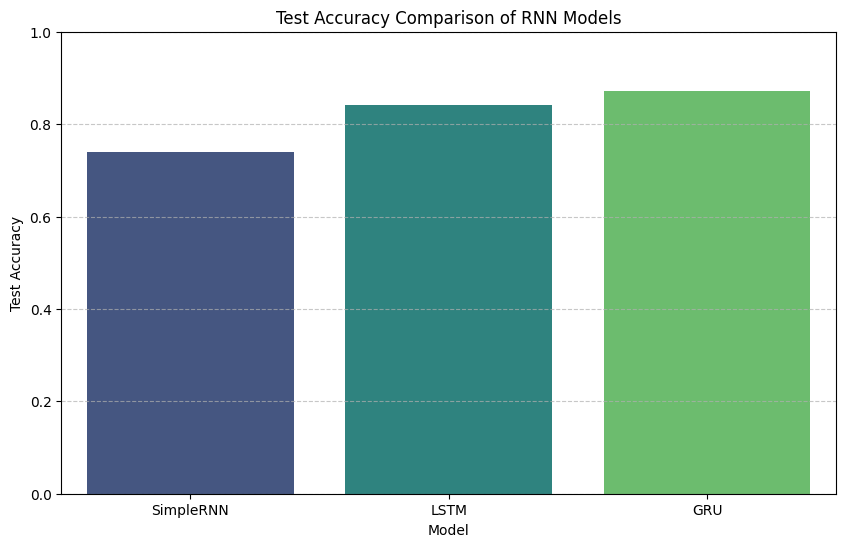

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- Accuracy Comparison Graph ---
plt.figure(figsize=(10, 6))
sns.barplot(x=comparison_df.index, y=comparison_df['Accuracy'], palette='viridis')
plt.title('Test Accuracy Comparison of RNN Models')
plt.xlabel('Model')
plt.ylabel('Test Accuracy')
plt.ylim(0, 1) # Accuracy ranges from 0 to 1
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


### Loss Comparison Graphs (Training and Validation)

Now, let's visualize the training and validation loss over epochs for each model. This helps in understanding convergence and potential overfitting.

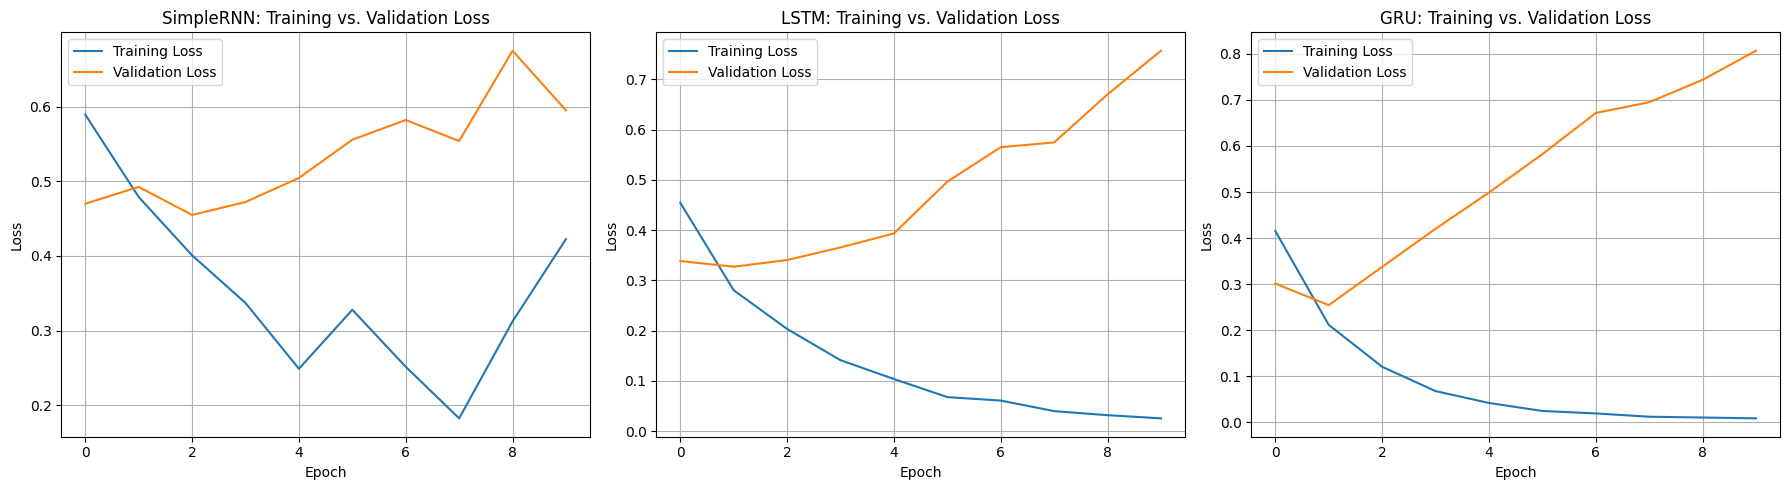

In [29]:
import matplotlib.pyplot as plt
# --- Loss Comparison Graph (SimpleRNN) ---
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1) # 1 row, 3 columns, 1st plot
plt.plot(history_simple_rnn.history['loss'], label='Training Loss')
plt.plot(history_simple_rnn.history['val_loss'], label='Validation Loss')
plt.title('SimpleRNN: Training vs. Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# --- Loss Comparison Graph (LSTM) ---
plt.subplot(1, 3, 2) # 1 row, 3 columns, 2nd plot
plt.plot(history_lstm_imdb.history['loss'], label='Training Loss')
plt.plot(history_lstm_imdb.history['val_loss'], label='Validation Loss')
plt.title('LSTM: Training vs. Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# --- Loss Comparison Graph (GRU) ---
plt.subplot(1, 3, 3) # 1 row, 3 columns, 3rd plot
plt.plot(history_gru_imdb.history['loss'], label='Training Loss')
plt.plot(history_gru_imdb.history['val_loss'], label='Validation Loss')
plt.title('GRU: Training vs. Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


### Task 8: Real-Time Testing

Let's test the trained SimpleRNN, LSTM, and GRU models with custom reviews to see their real-time prediction capabilities.

In [30]:
import re
import string

def predict_sentiment(model, text):
    # Preprocess the text: lowercase and remove punctuation
    cleaned_text = text.lower()
    cleaned_text = re.sub(f"[{re.escape(string.punctuation)}]", "", cleaned_text)
    words = cleaned_text.split()

    # Convert words to integer sequence using the IMDB word_index.
    # IMDB's `load_data` applies an offset: 0 for padding, 1 for start, 2 for unknown, and `word_index` values + 3 for actual words.
    sequence = []
    for word in words:
        word_idx_from_map = word_index.get(word)
        if word_idx_from_map is not None:
            # Add 3 to match the offset used in IMDB loaded sequences
            sequence.append(word_idx_from_map + 3)
        else:
            # Use 2 for unknown words (OOV token in IMDB)
            sequence.append(2)

    # Pad the sequence to the maximum length determined for the IMDB dataset
    padded_sequence = pad_sequences([sequence], maxlen=MAX_SEQUENCE_LENGTH)

    # Get prediction from the model
    prediction = model.predict(padded_sequence, verbose=0)[0][0]

    if prediction >= 0.5:
        return 'Positive', prediction
    else:
        return 'Negative', prediction

In [31]:
custom_reviews = [
    "This movie was absolutely fantastic and I enjoyed every minute.",
    "The movie was boring and a complete waste of time.",
    "The acting was good but the story was average.",
    "An inspiring and uplifting film with brilliant performances.",
    "Terrible plot, confusing narrative, and poor acting. Avoid at all costs."
]

models_to_test = {
    "SimpleRNN": simple_rnn_model,
    "LSTM": lstm_model_imdb,
    "GRU": gru_model_imdb
}

for model_name, model in models_to_test.items():
    print(f"\n--- {model_name} Model Predictions ---")
    for i, review in enumerate(custom_reviews):
        sentiment, score = predict_sentiment(model, review)
        print(f"Review {i+1}: '{review}'")
        print(f"Predicted Sentiment: {sentiment}, Confidence Score: {score:.4f}")



--- SimpleRNN Model Predictions ---
Review 1: 'This movie was absolutely fantastic and I enjoyed every minute.'
Predicted Sentiment: Positive, Confidence Score: 0.7792
Review 2: 'The movie was boring and a complete waste of time.'
Predicted Sentiment: Negative, Confidence Score: 0.0735
Review 3: 'The acting was good but the story was average.'
Predicted Sentiment: Positive, Confidence Score: 0.7050
Review 4: 'An inspiring and uplifting film with brilliant performances.'
Predicted Sentiment: Positive, Confidence Score: 0.9129
Review 5: 'Terrible plot, confusing narrative, and poor acting. Avoid at all costs.'
Predicted Sentiment: Negative, Confidence Score: 0.0005

--- LSTM Model Predictions ---
Review 1: 'This movie was absolutely fantastic and I enjoyed every minute.'
Predicted Sentiment: Positive, Confidence Score: 0.9931
Review 2: 'The movie was boring and a complete waste of time.'
Predicted Sentiment: Negative, Confidence Score: 0.0025
Review 3: 'The acting was good but the story

In [32]:
# Save Simple RNN
simple_rnn_model.save("simple_rnn_model.keras")

# Save LSTM
lstm_model_imdb.save("lstm_model.keras")

# Save GRU
gru_model_imdb.save("gru_model.keras")

In [34]:
import pickle

# Save the word_index dictionary used for IMDB dataset
with open("imdb_word_index.pkl", "wb") as f:
    pickle.dump(word_index, f)

# Save MAX_SEQUENCE_LENGTH as it's crucial for padding new inputs
with open("max_sequence_length.pkl", "wb") as f:
    pickle.dump(MAX_SEQUENCE_LENGTH, f)
